# Distribution Visualizer — Самоучитель

Этот ноутбук покажет тебе все возможности библиотеки на живых примерах.

**Что умеет библиотека:**
- Автоматически определяет тип каждой колонки (непрерывный, дискретный, категориальный)
- Строит подходящий график для каждого типа
- Показывает среднее и медиану на каждом графике
- Работает с любым pandas DataFrame

## Шаг 1. Установка

Запусти эту ячейку — она скачает библиотеку прямо в текущую папку.

In [1]:
import urllib.request
import zipfile
import os

url = "https://github.com/Russel63/Distribution-Visualizer/archive/refs/heads/main.zip"
urllib.request.urlretrieve(url, "visualizer.zip")

with zipfile.ZipFile("visualizer.zip") as z:
    z.extract("Distribution-Visualizer-main/visualizer.py")

os.rename("Distribution-Visualizer-main/visualizer.py", "visualizer.py")
os.remove("visualizer.zip")
os.rmdir("Distribution-Visualizer-main")

print("✓ Готово!")

✓ Готово!


## Шаг 2. Импорт

In [2]:
import pandas as pd
import numpy as np
from visualizer import plt_distr

## Шаг 3. Подготовим данные

Создадим датафрейм с разными типами колонок — как в реальных задачах.

In [3]:
np.random.seed(42)
n = 1000

df = pd.DataFrame({
    'age':        np.random.randint(18, 70, n),                          # дискретный
    'salary':     np.random.normal(60000, 20000, n),                     # непрерывный
    'children':   np.random.randint(0, 5, n),                            # дискретный
    'experience': np.random.randint(0, 40, n),                           # дискретный
    'score':      np.random.uniform(0, 100, n),                          # непрерывный
    'city':       np.random.choice(['Москва', 'СПб', 'Казань', 'Екб', 'Новосибирск'], n),  # категориальный
    'status':     np.random.choice(['Активный', 'Неактивный', 'Заблокирован'], n, p=[0.7, 0.2, 0.1]),
})

print("Датафрейм создан:", df.shape)
df.head()

Датафрейм создан: (1000, 7)


,age,salary,children,experience,score,city,status
0,56,27871.073595,4,19,10.097811,СПб,Активный
1,69,64069.272717,1,27,16.749109,Новосибирск,Неактивный
2,46,44872.985094,3,15,14.727556,Казань,Активный
3,32,31554.925808,4,16,97.307680,Казань,Активный
4,60,47068.542315,3,39,75.929251,Москва,Активный


## Пример 1. Базовый вызов

Просто передай датафрейм — библиотека сама разберётся что и как рисовать.

Обрати внимание на сообщение `⚠️ Автоопределение типов` — оно показывает как библиотека классифицировала каждую колонку. Если что-то определилось неверно — смотри Пример 6.

⚠️  Автоопределение типов: дискретные → ['age', 'children', 'experience'], непрерывные → ['salary', 'score']
   Если график отображается некорректно, передайте списки вручную: discrete_cols=[...] или all_discrete_cols=[...]


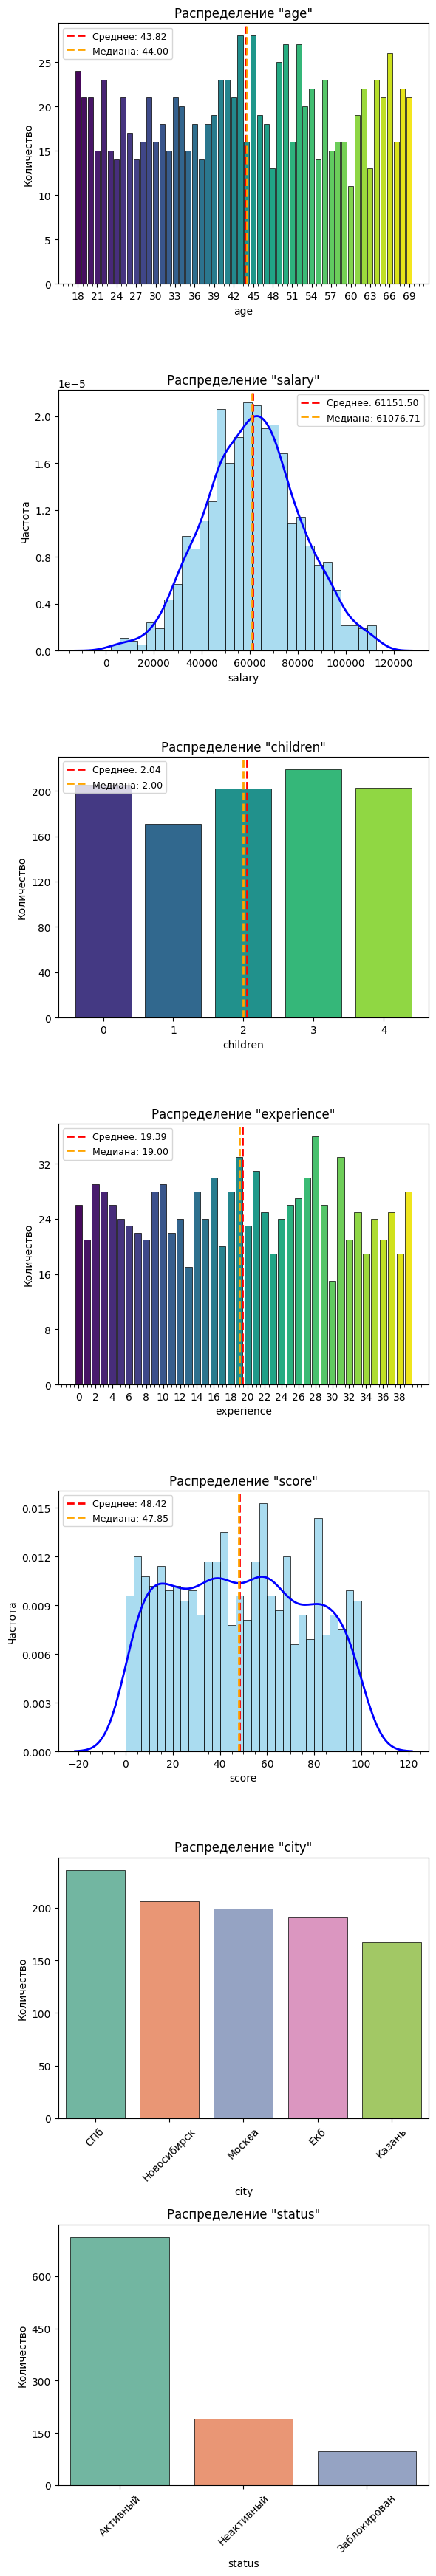

In [4]:
plt_distr(df)

## Пример 2. Два графика в ряд

Параметр `ncols=2` позволяет разместить два графика рядом — удобно когда колонок много и хочется просмотреть их быстрее.

⚠️  Автоопределение типов: дискретные → ['age', 'children', 'experience'], непрерывные → ['salary', 'score']
   Если график отображается некорректно, передайте списки вручную: discrete_cols=[...] или all_discrete_cols=[...]


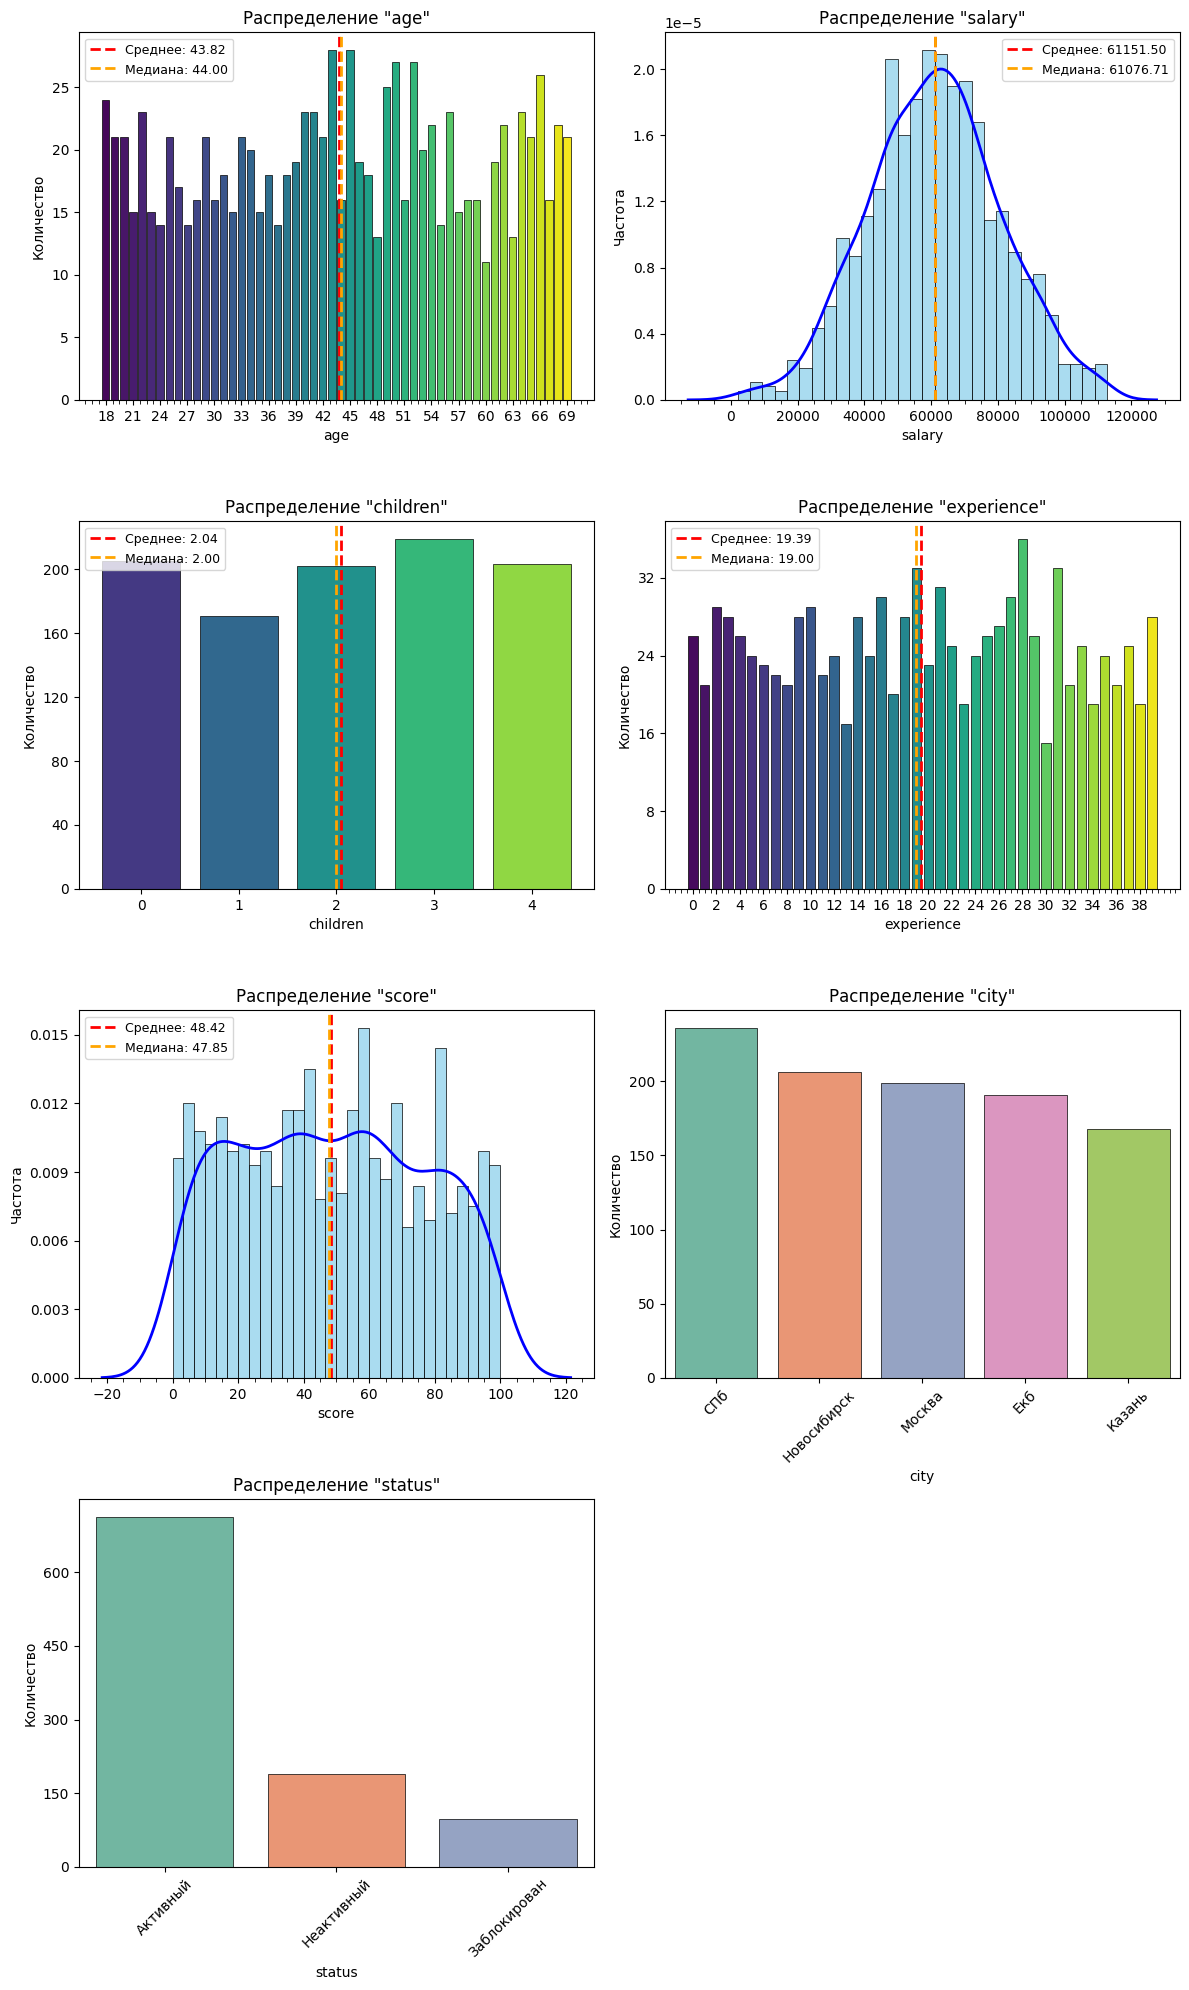

In [5]:
plt_distr(df, ncols=2)

## Пример 3. Красивые названия колонок

Технические названия колонок (`salary`, `age`) не всегда понятны коллегам.  
Передай словарь `col_names` чтобы заменить их на читаемые названия.

Не обязательно указывать все колонки — пропущенные останутся с оригинальным именем.

⚠️  Автоопределение типов: дискретные → ['age', 'children', 'experience'], непрерывные → ['salary', 'score']
   Если график отображается некорректно, передайте списки вручную: discrete_cols=[...] или all_discrete_cols=[...]


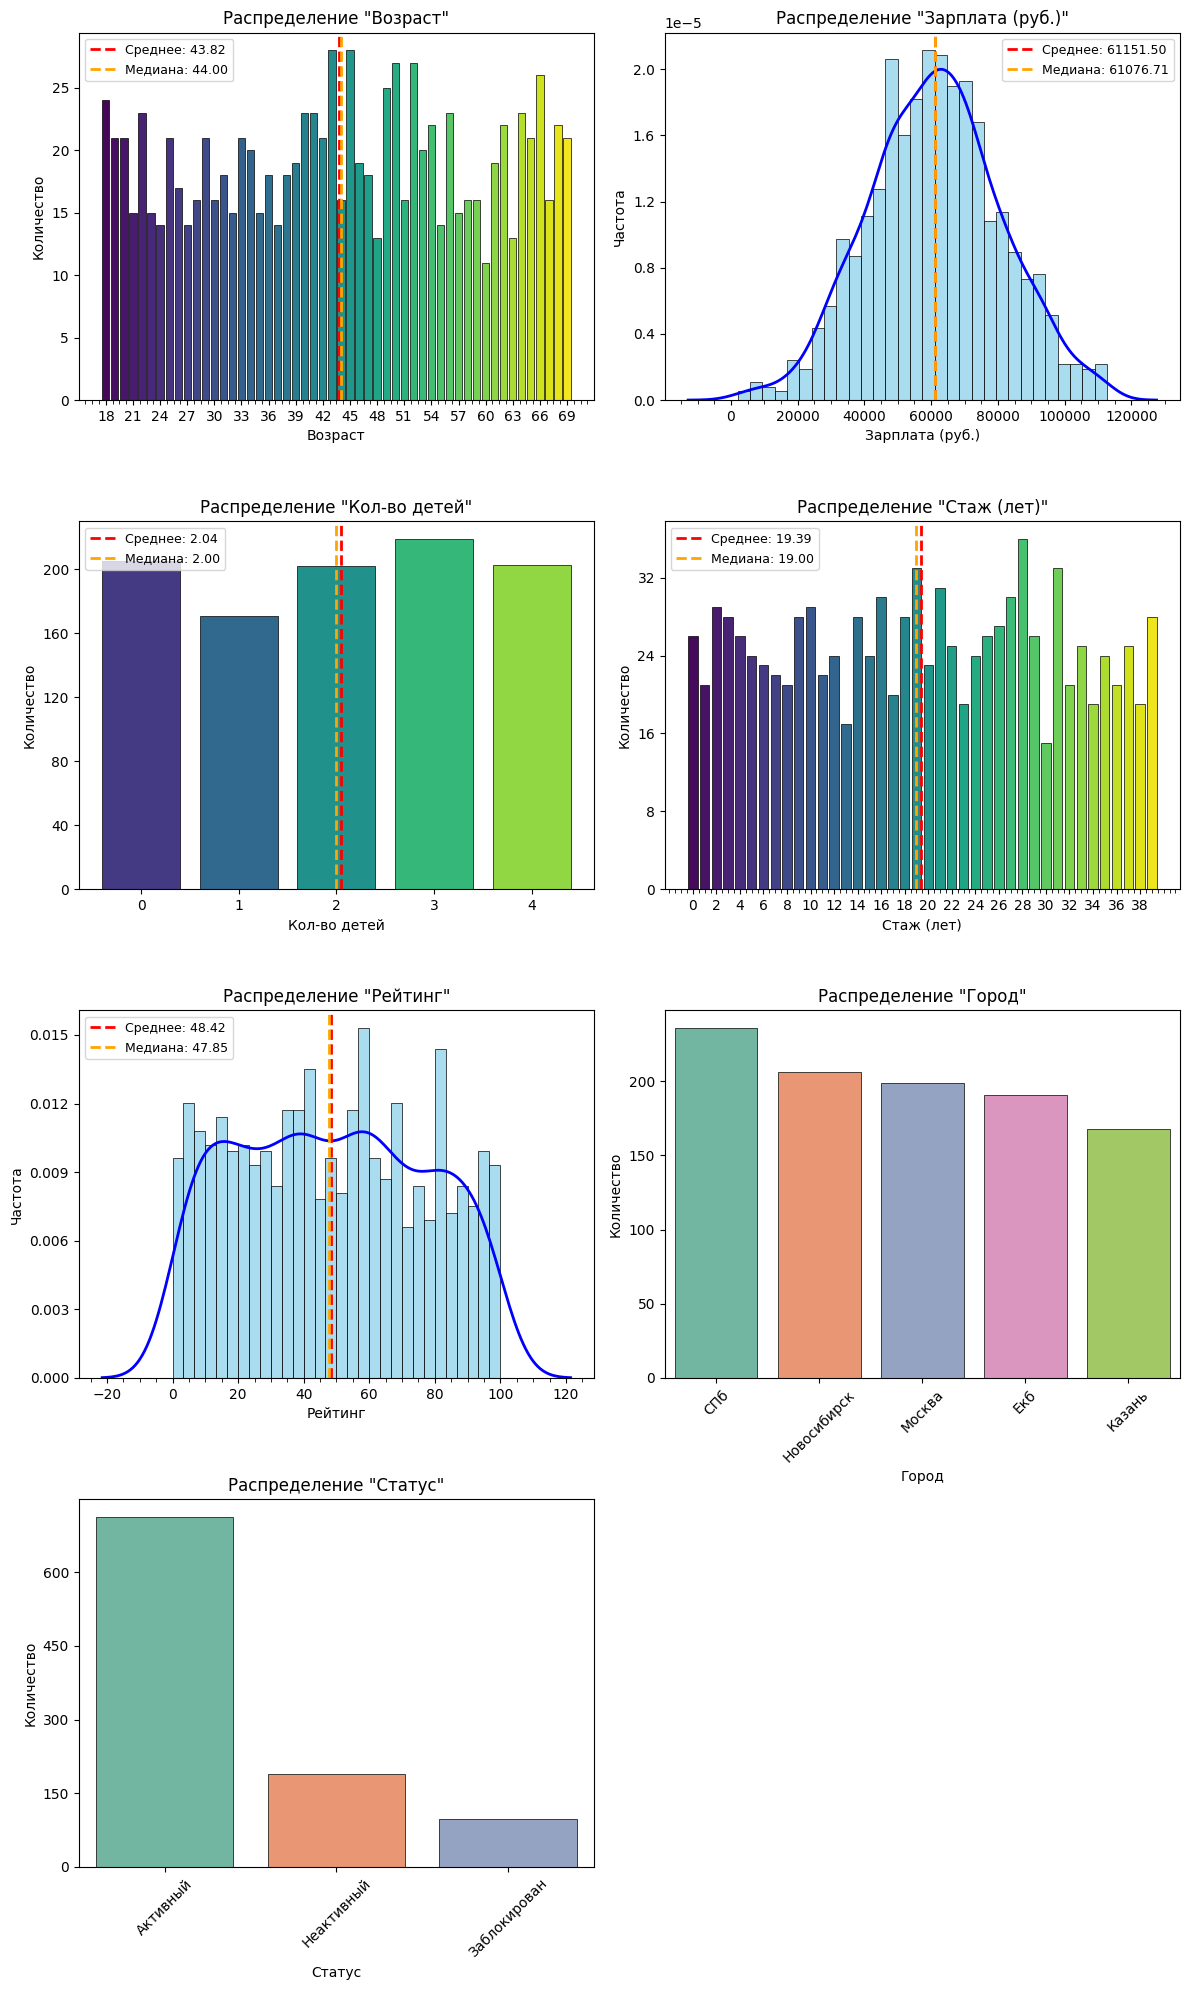

In [6]:
col_names = {
    'age':        'Возраст',
    'salary':     'Зарплата (руб.)',
    'children':   'Кол-во детей',
    'experience': 'Стаж (лет)',
    'score':      'Рейтинг',
    'city':       'Город',
    'status':     'Статус',
}

plt_distr(df, col_names=col_names, ncols=2)

## Пример 4. Доверительный интервал

Параметр `interval=0.95` добавляет две зелёные линии на непрерывных графиках.  
Между ними находится 95% всех значений — это помогает увидеть где сосредоточена основная масса данных и насколько сильны выбросы.

Можно использовать любое значение от 0 до 1, например `0.90` или `0.99`.

⚠️  Автоопределение типов: дискретные → ['age', 'children', 'experience'], непрерывные → ['salary', 'score']
   Если график отображается некорректно, передайте списки вручную: discrete_cols=[...] или all_discrete_cols=[...]


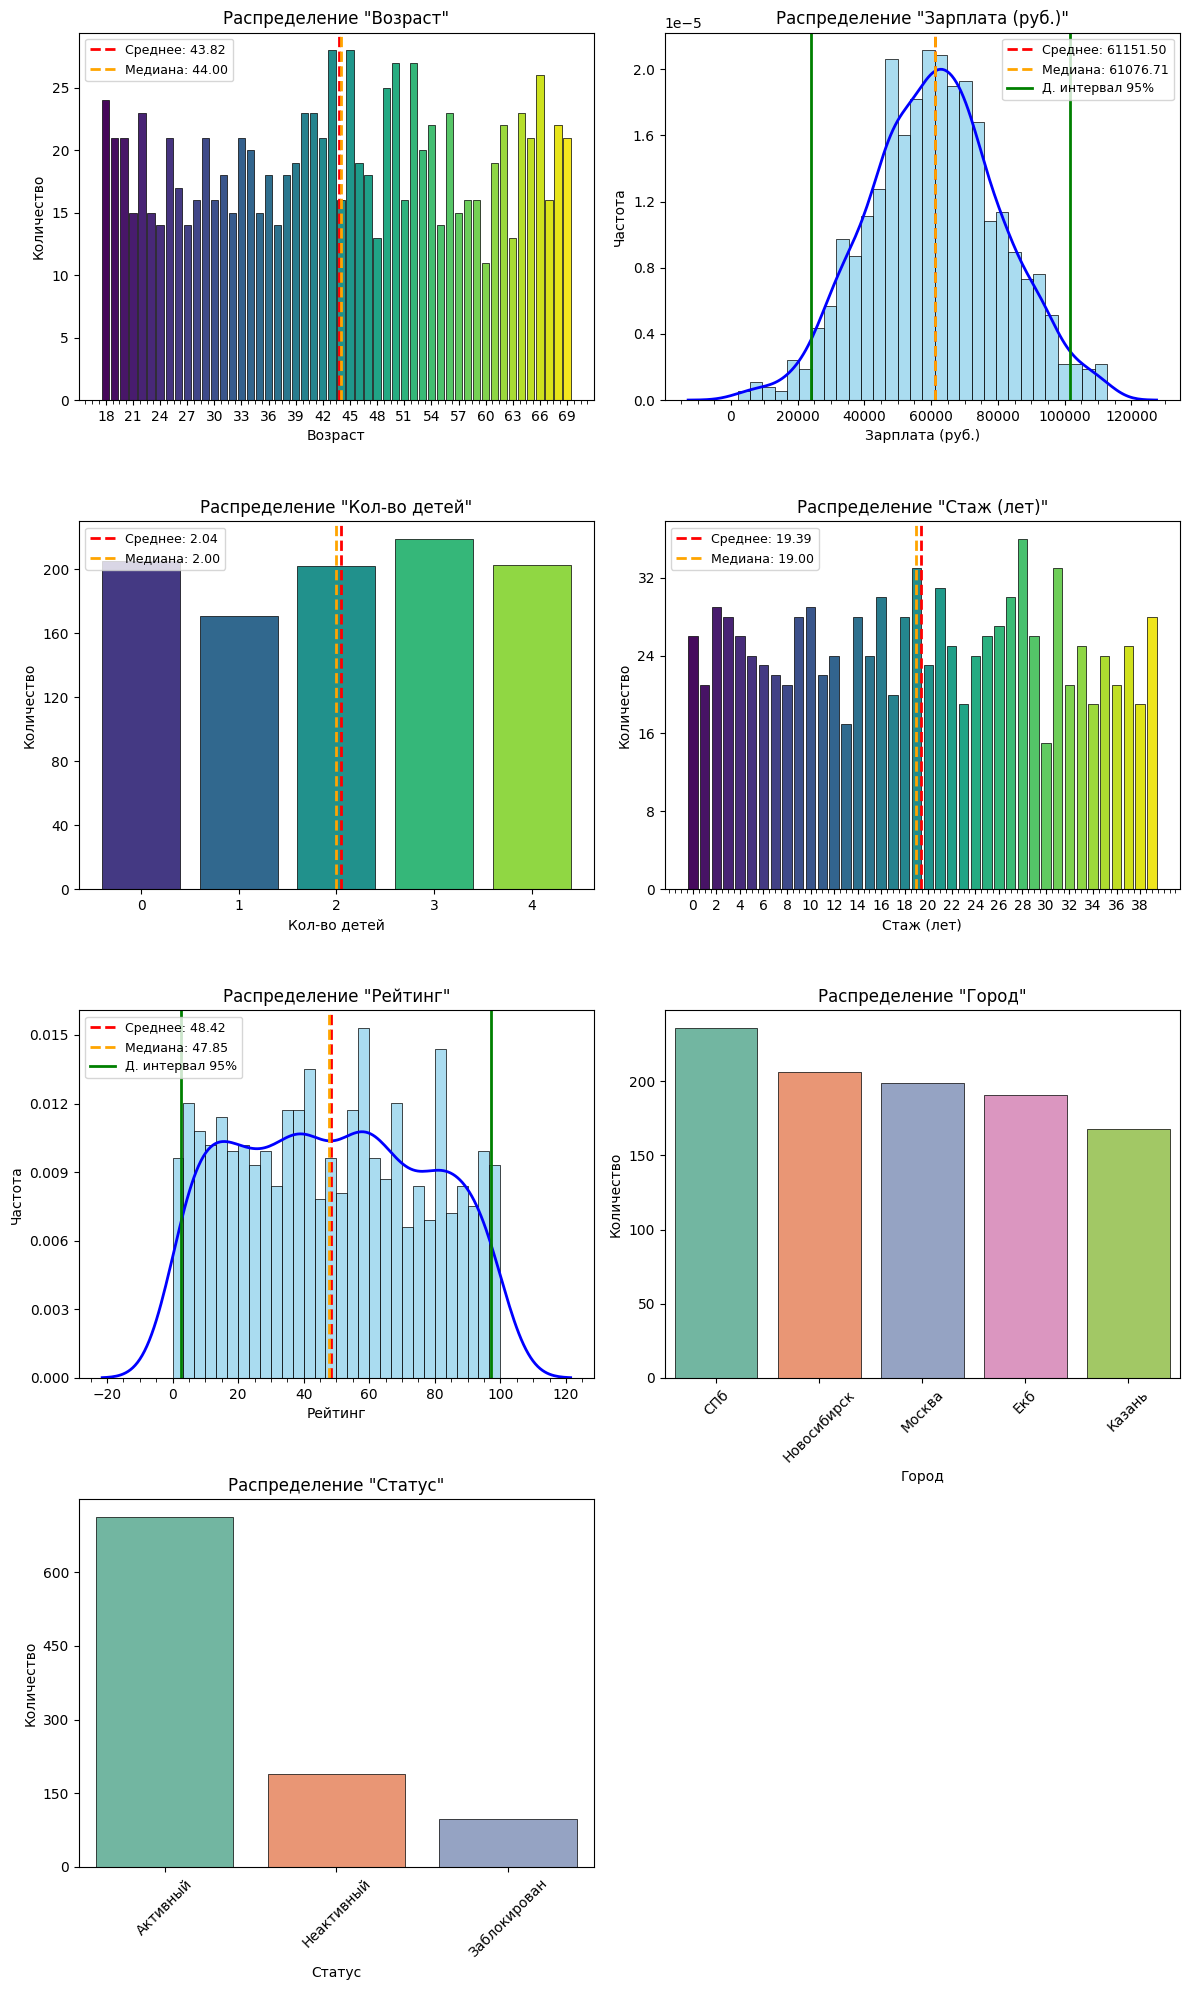

In [7]:
plt_distr(df, col_names=col_names, interval=0.95, ncols=2)

## Пример 5. Зона рисков

Параметр `zones` закрашивает красным указанные диапазоны значений на непрерывных графиках.  
Это полезно когда ты заранее знаешь какие значения являются проблемными.

Формат: `zones=[(нижняя_граница, верхняя_граница), ...]`

Можно указать несколько зон сразу.

**Примеры применения:**
- Зарплаты ниже прожиточного минимума
- Медицинские показатели вне нормы
- Скор модели ниже допустимого порога

⚠️  Автоопределение типов: дискретные → ['age', 'children', 'experience'], непрерывные → ['salary', 'score']
   Если график отображается некорректно, передайте списки вручную: discrete_cols=[...] или all_discrete_cols=[...]


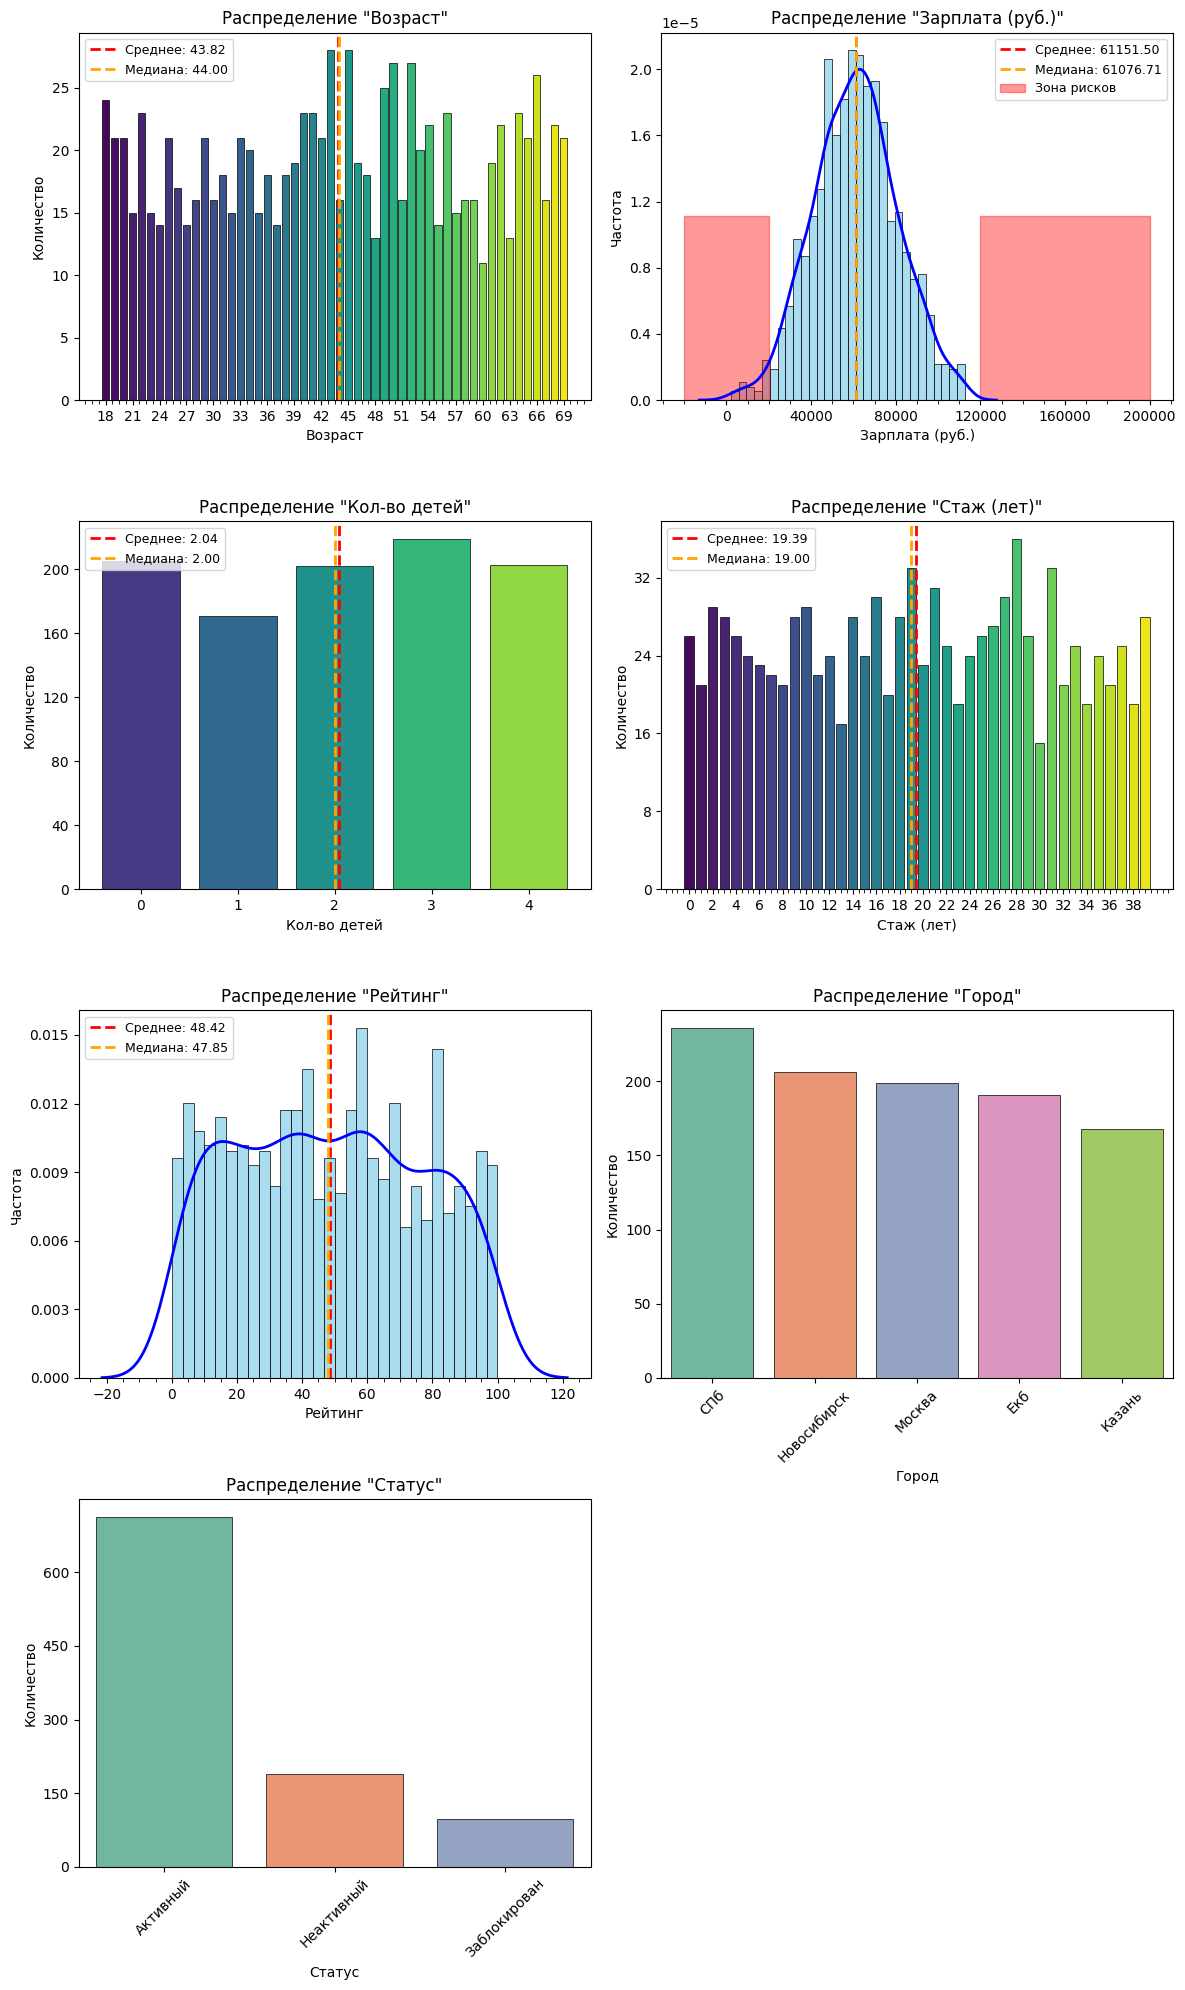

In [8]:
# Зоны рисков только для колонки salary
plt_distr(df, col_names=col_names, zones=[(0, 20000), (120000, 200000)], zones_cols=['salary'], ncols=2)

## Пример 6. Если график отобразился неверно

Иногда алгоритм ошибается. Например, `experience` (стаж) может определиться как непрерывный, хотя это дискретный признак.

**Вариант А** — добавить колонки к автоматически найденным дискретным:

⚠️  Автоопределение типов: дискретные → ['age', 'children', 'experience'], непрерывные → ['salary', 'score']
   Если график отображается некорректно, передайте списки вручную: discrete_cols=[...] или all_discrete_cols=[...]


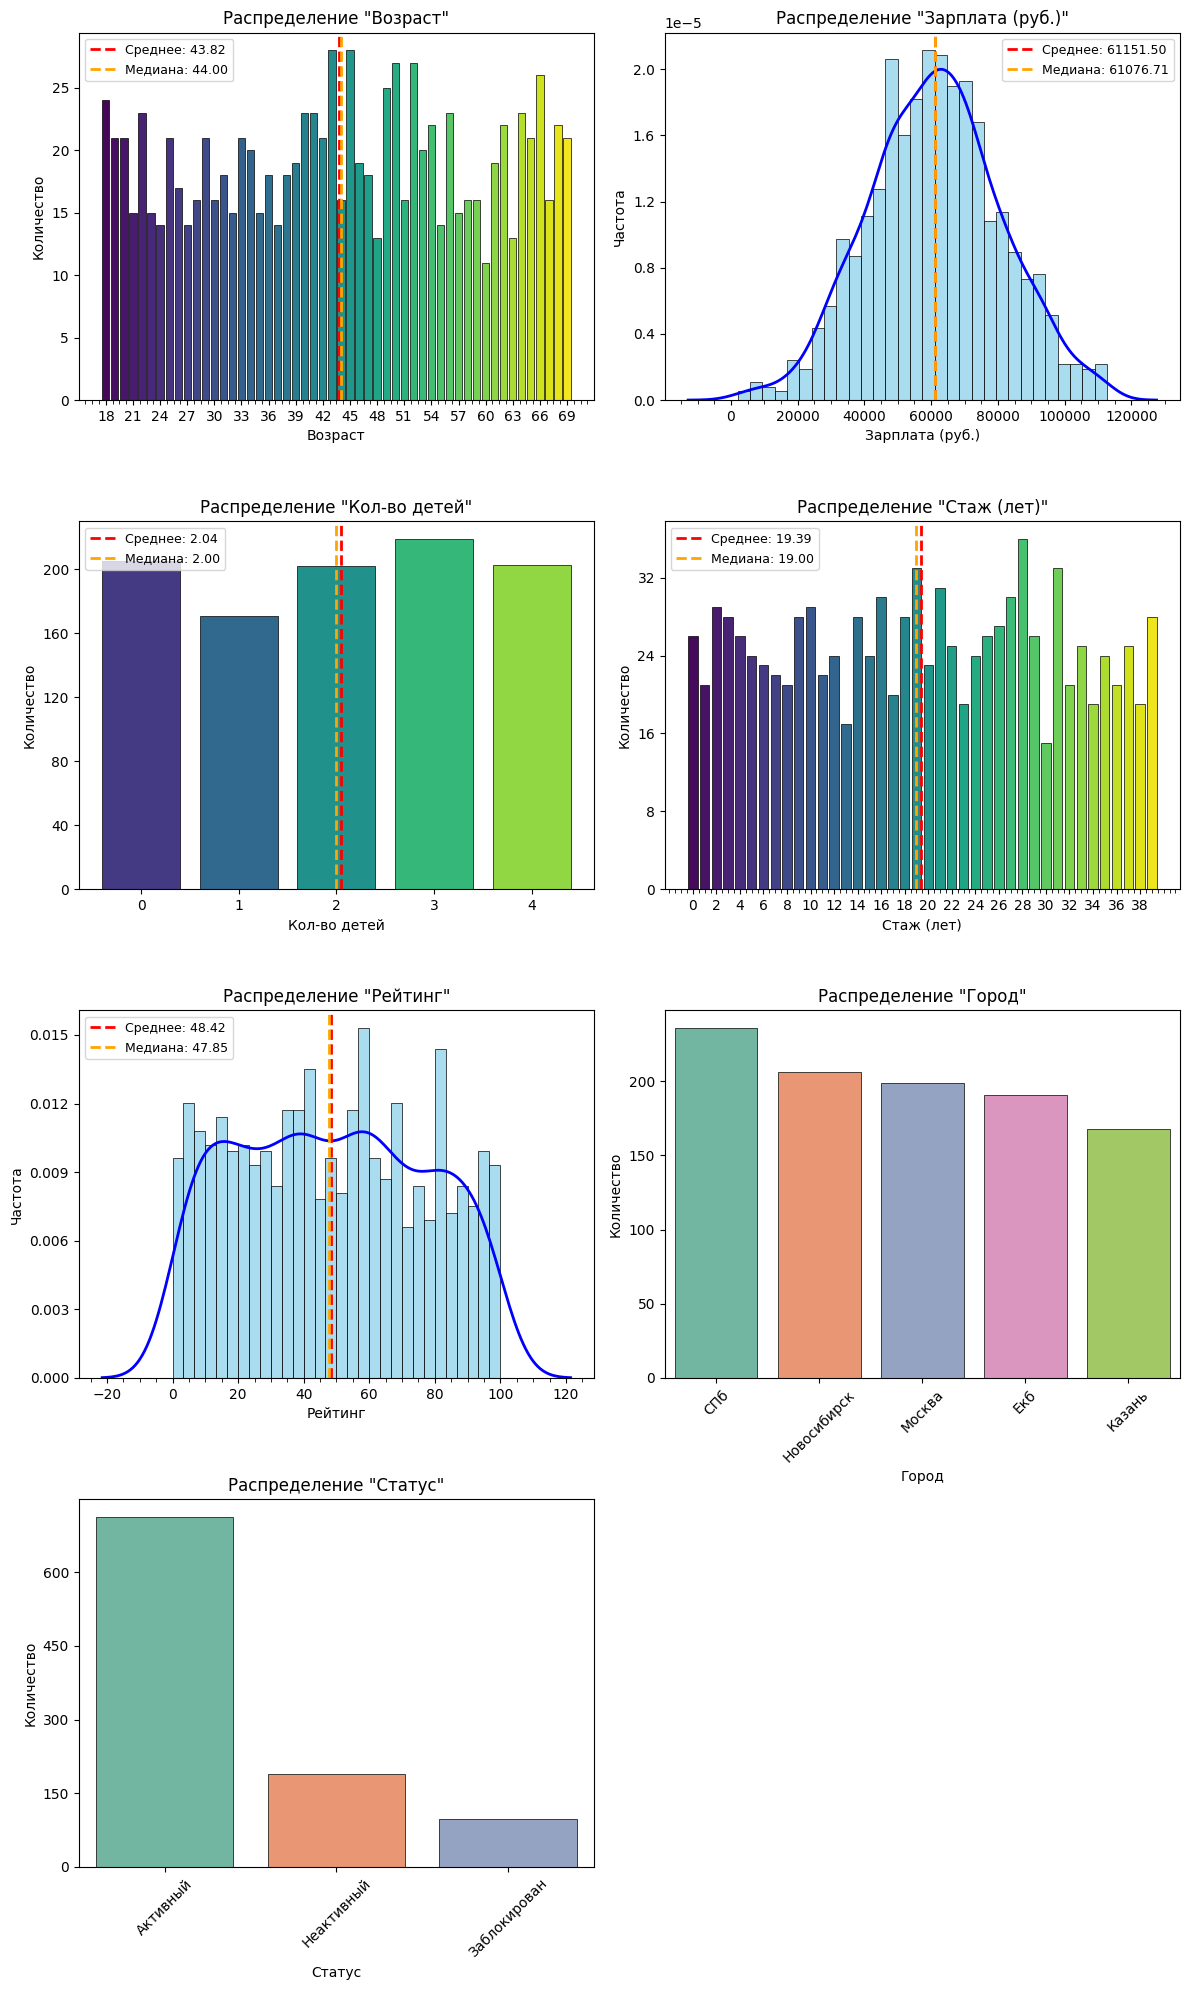

In [9]:
plt_distr(df, col_names=col_names, discrete_cols=['experience'], ncols=2)

**Вариант Б** — задать полный список дискретных колонок вручную (отключает автоопределение полностью):

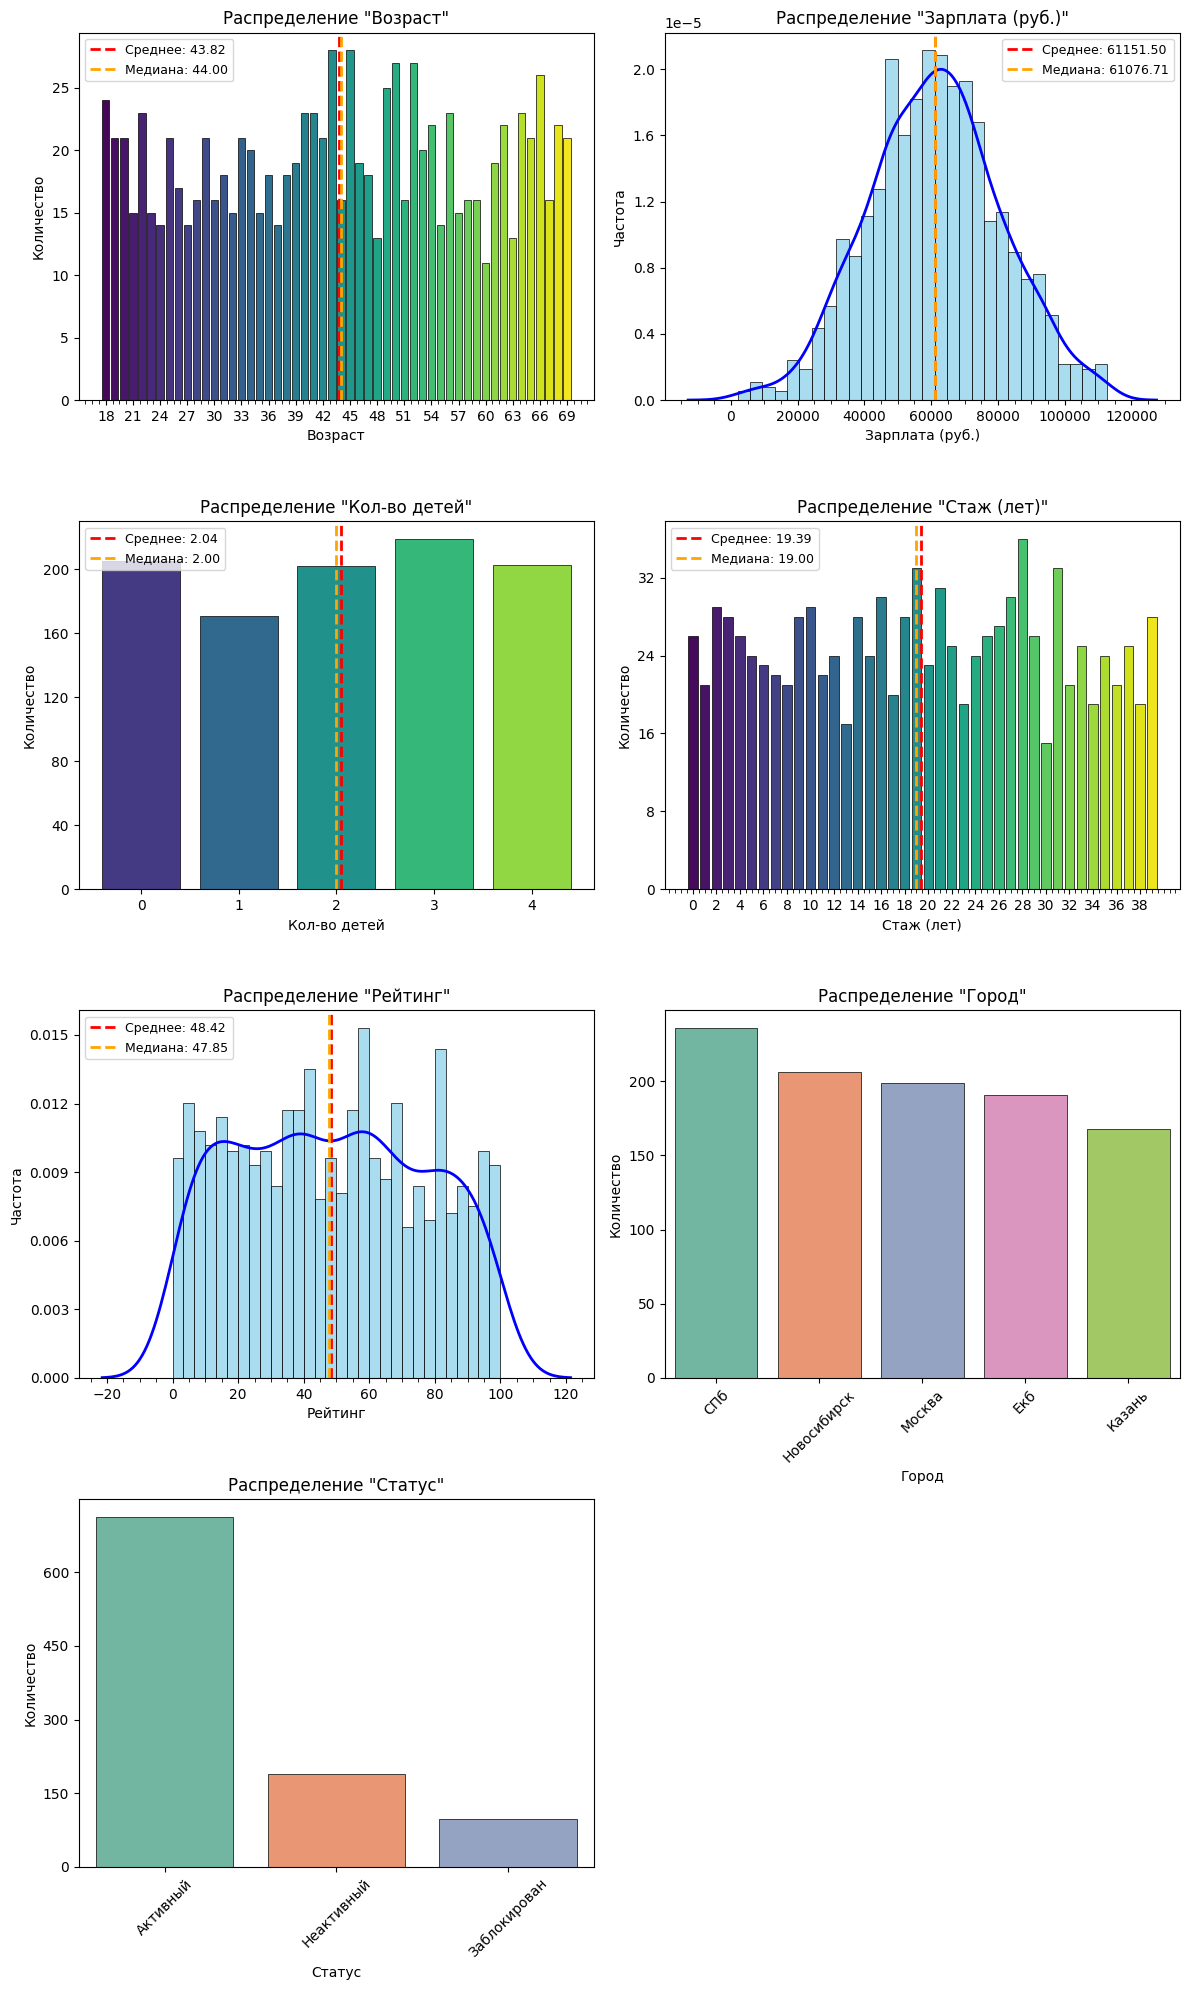

In [10]:
plt_distr(df, col_names=col_names, all_discrete_cols=['age', 'children', 'experience'], ncols=2)

## Пример 7. Ограничить число категорий

Если в категориальной колонке много уникальных значений — график становится нечитаемым.  
Параметр `max_cat_values` ограничивает число отображаемых категорий (по умолчанию 20 — топ по частоте).

⚠️  Автоопределение типов: дискретные → [], непрерывные → []
   Если график отображается некорректно, передайте списки вручную: discrete_cols=[...] или all_discrete_cols=[...]


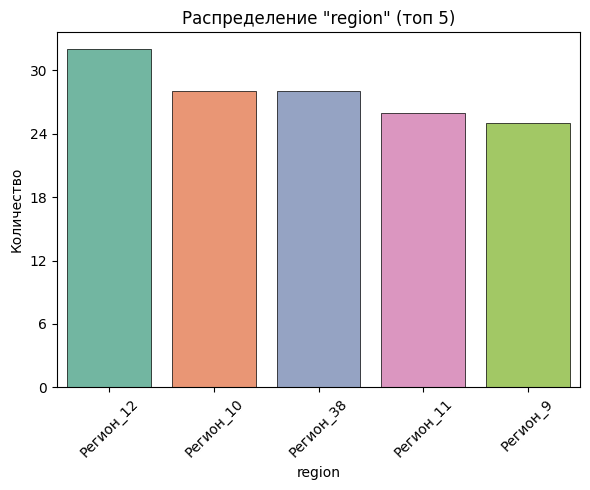

In [11]:
# Создадим колонку с большим числом категорий
df['region'] = np.random.choice([f'Регион_{i}' for i in range(50)], n)

# Покажем только топ-5
plt_distr(df[['region']], max_cat_values=5)

## Пример 8. Максимальный вызов

Все параметры вместе:

⚠️  Автоопределение типов: дискретные → ['age', 'children', 'experience'], непрерывные → ['salary', 'score']
   Если график отображается некорректно, передайте списки вручную: discrete_cols=[...] или all_discrete_cols=[...]


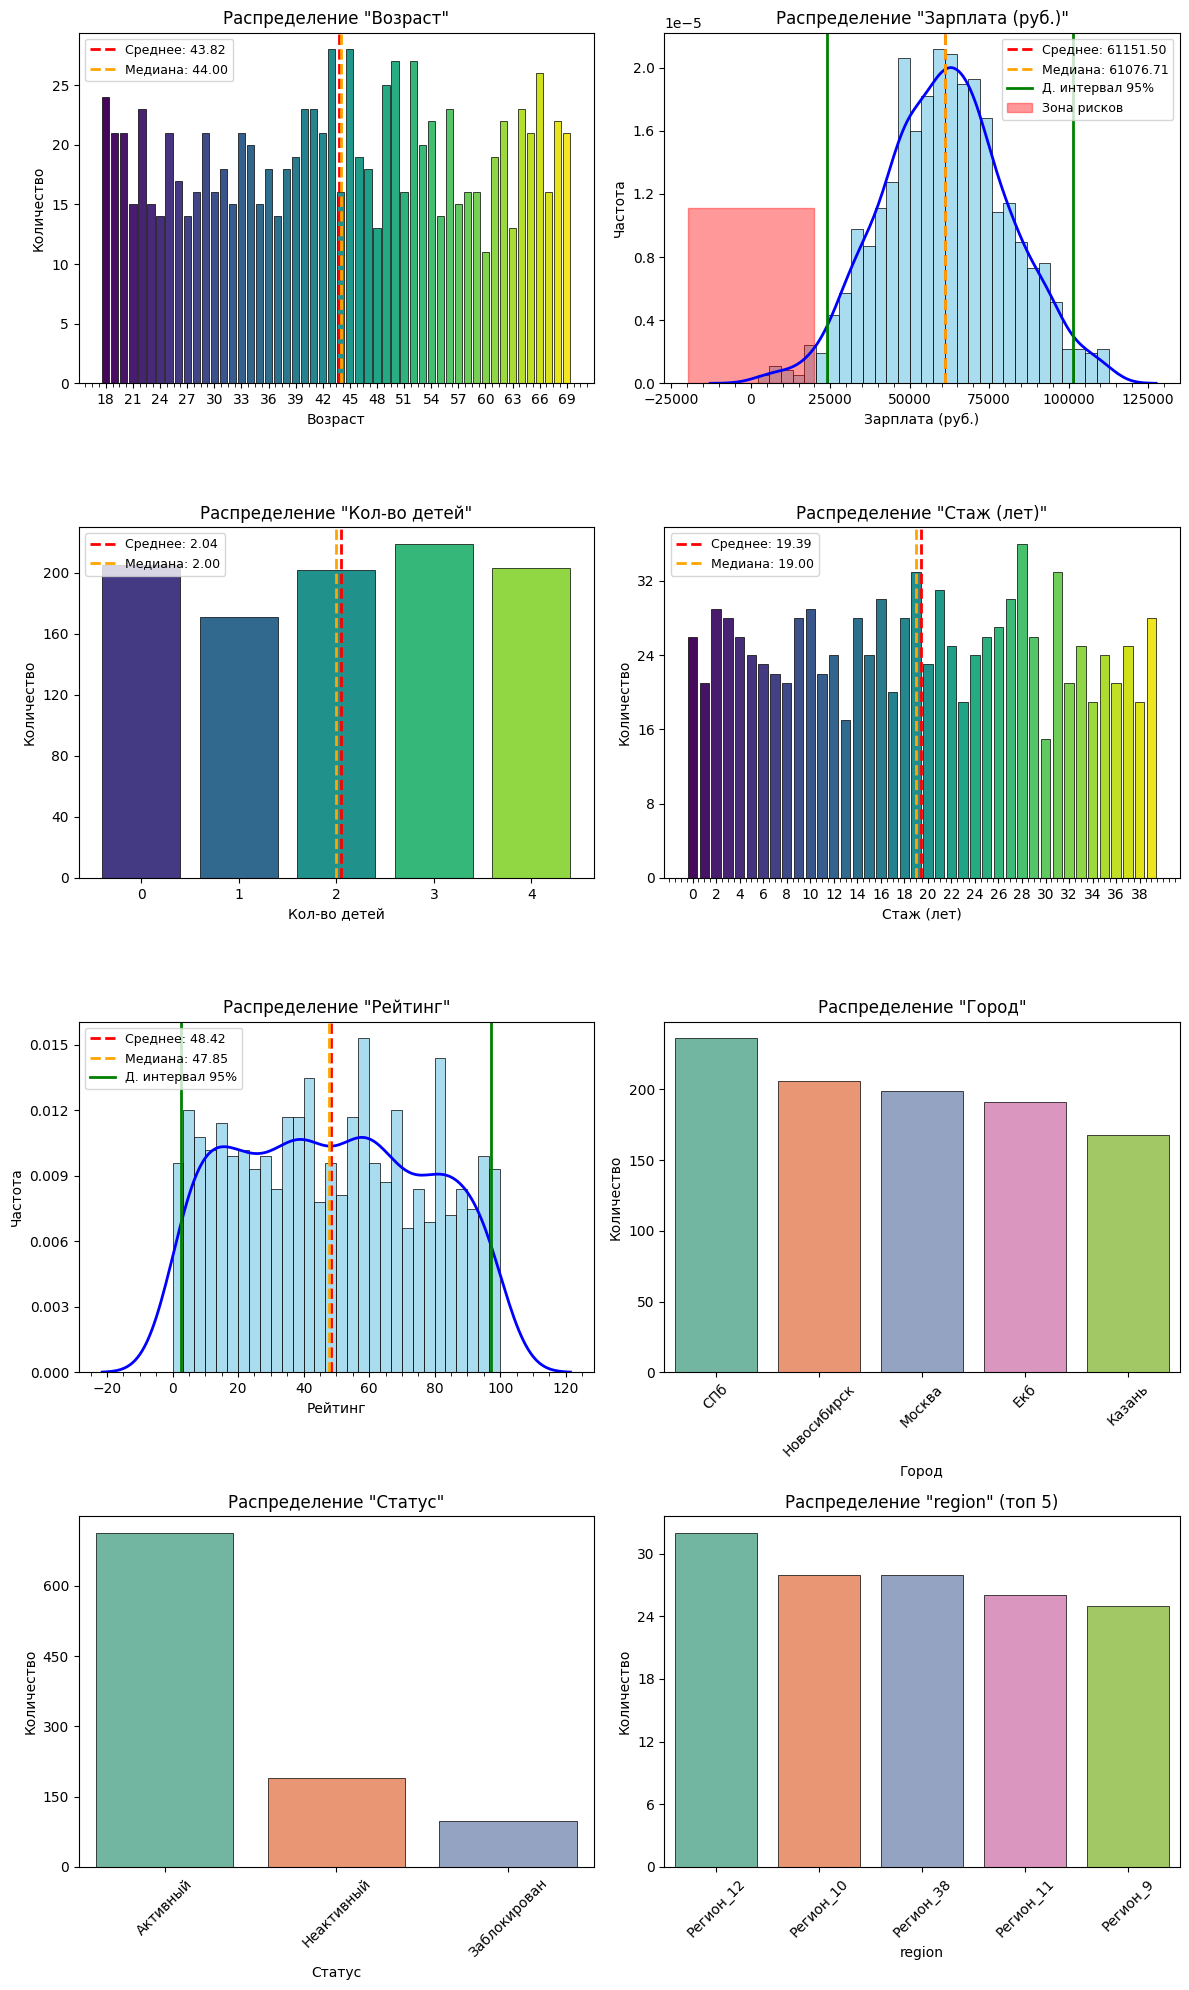

In [12]:
plt_distr(
    df,
    col_names=col_names,
    discrete_cols=['experience'],   # добавить к автоопределённым
    interval=0.95,                  # доверительный интервал
    zones=[(0, 20000)],             # зона рисков
    zones_cols=['salary'],          # только для колонки salary
    ncols=2,                        # два графика в ряд
    max_cat_values=5,               # топ-5 категорий
)

## Справочник параметров

| Параметр | Тип | По умолчанию | Описание |
|---|---|---|---|
| `df` | DataFrame | — | Входной датафрейм |
| `title` | bool | `True` | Показывать заголовок из `df.attrs["title"]` |
| `col_names` | dict | `None` | Словарь `{'колонка': 'Название'}` |
| `discrete_cols` | list | `None` | Добавить колонки к автоопределённым дискретным |
| `all_discrete_cols` | list | `None` | Задать все дискретные колонки вручную |
| `interval` | float | `False` | Доверительный интервал, например `0.95` |
| `zones` | list | `False` | Зоны рисков в формате `[(low, high), ...]` |
| `ncols` | int | `1` | Количество графиков в одном ряду |
| `max_cat_values` | int | `20` | Максимум категорий на графике |